In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 16


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

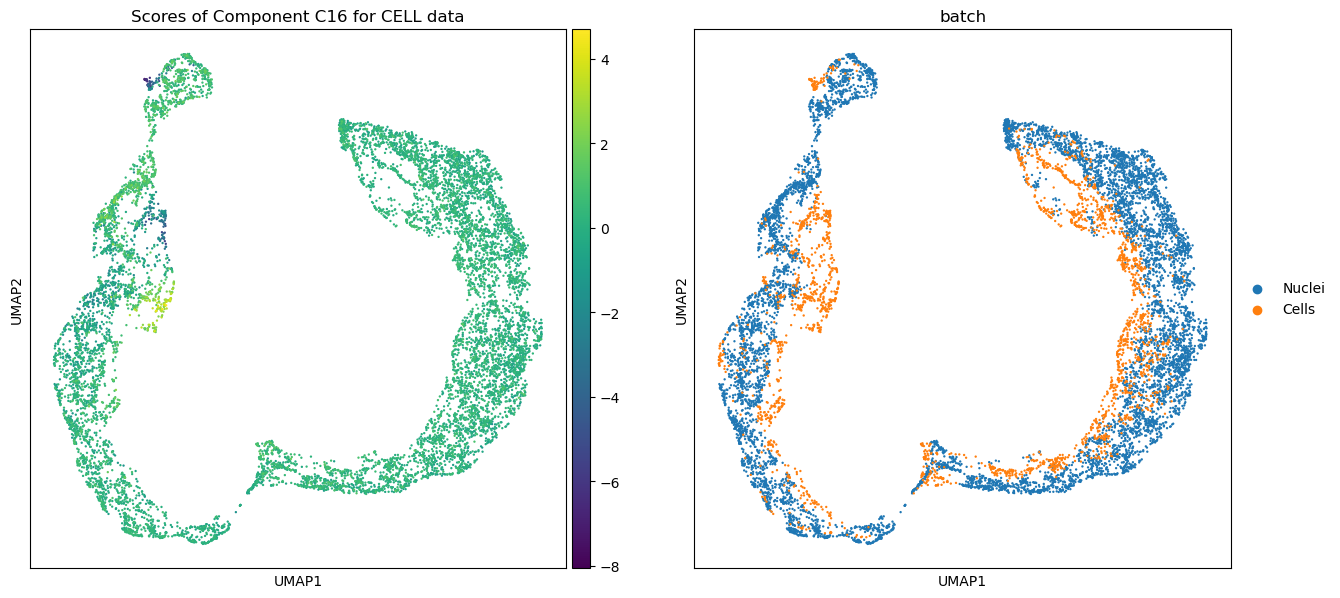

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

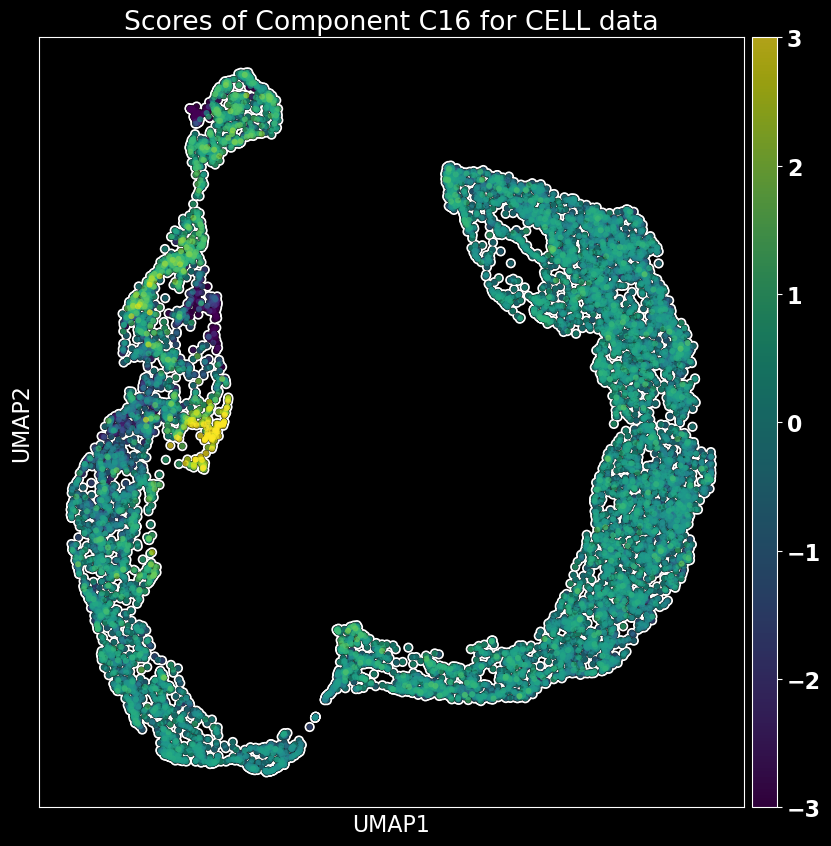

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

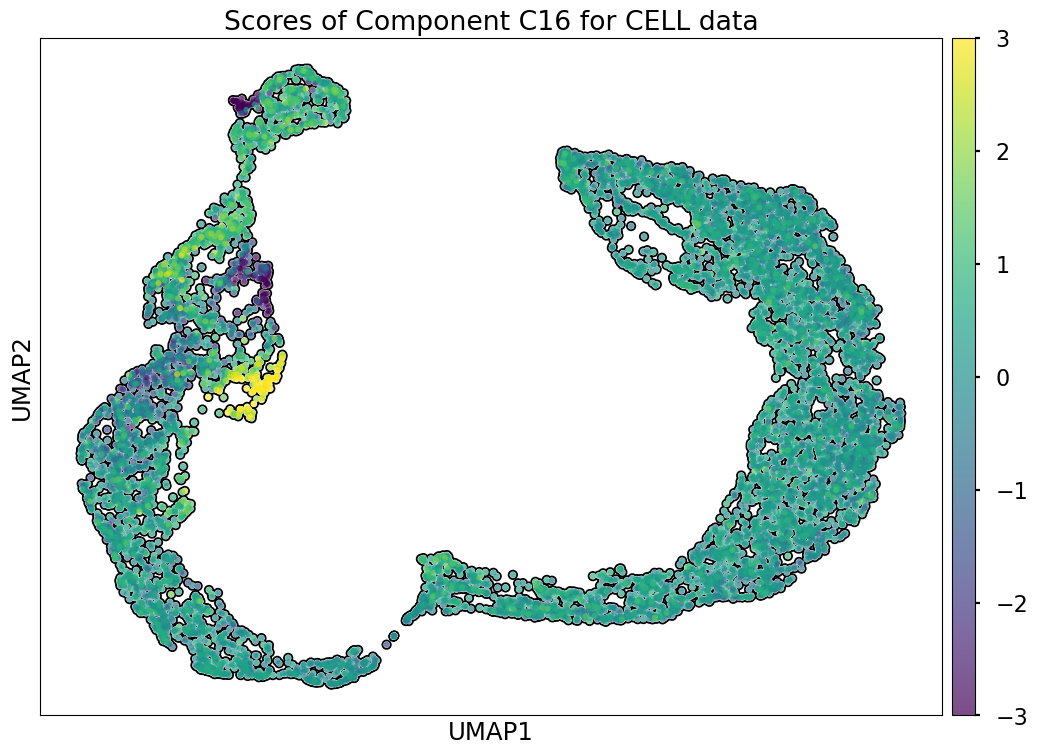

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

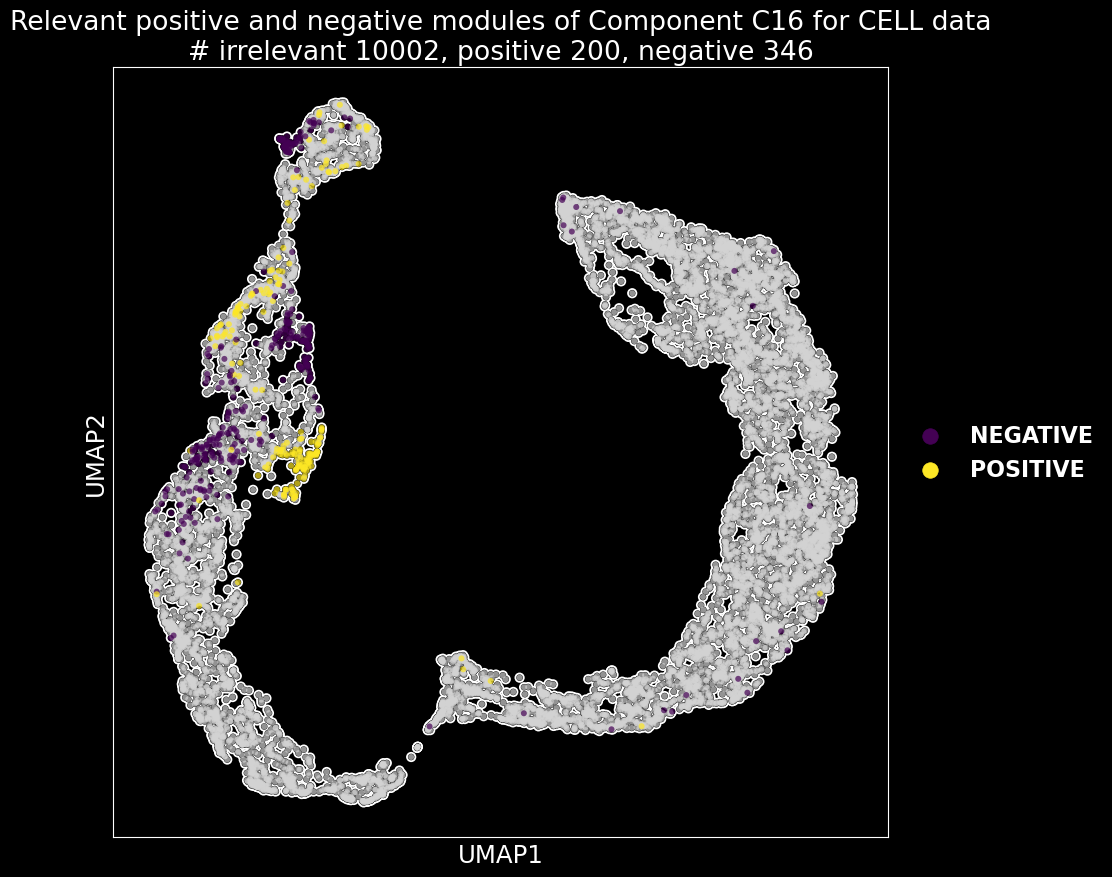

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

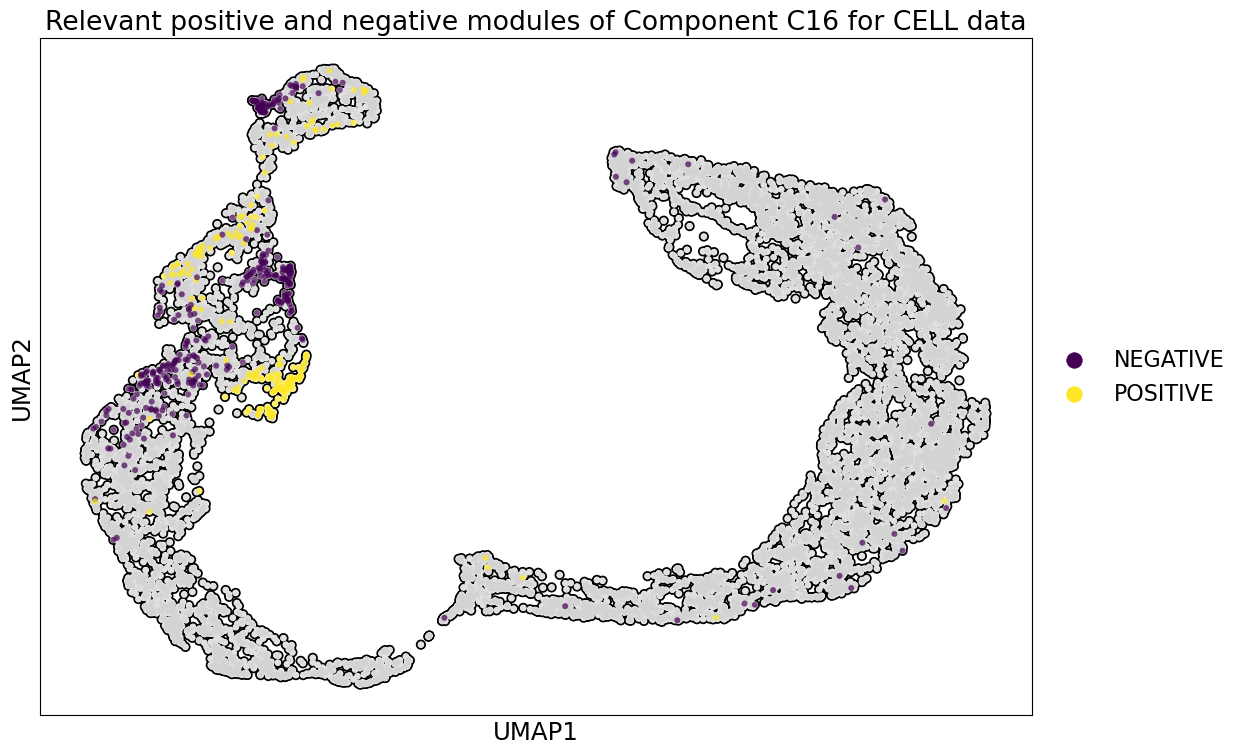

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.8207404494382025 var: 0.28655320502466963
Positive scores cells  - mean: 2.877108558558558 var: 0.5922548040379498


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.9732834285714287 var: 0.4809350771471453
Negative scores cells  - mean: -3.7350516959064324 var: 1.3572188305665716


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=13.34116436598855, pvalue=5.639674981249827e-40)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-21.13602361261589, pvalue=3.957509312971568e-95)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C16', ylabel='Count'>

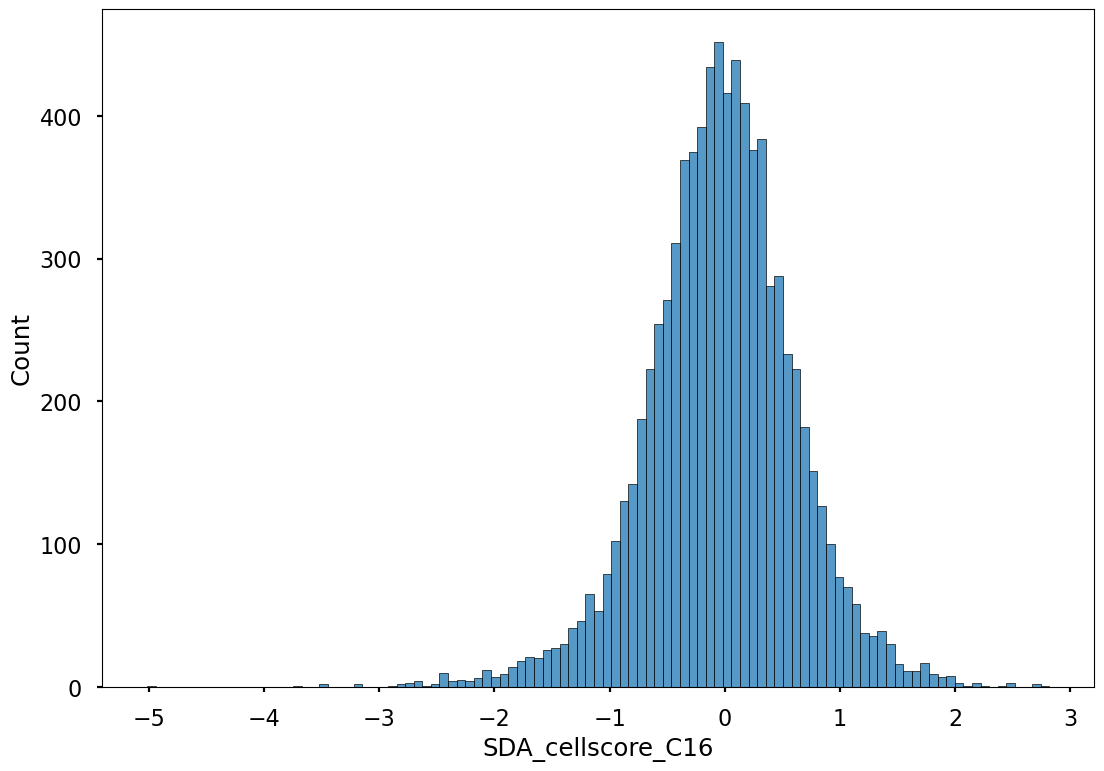

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C16', ylabel='Count'>

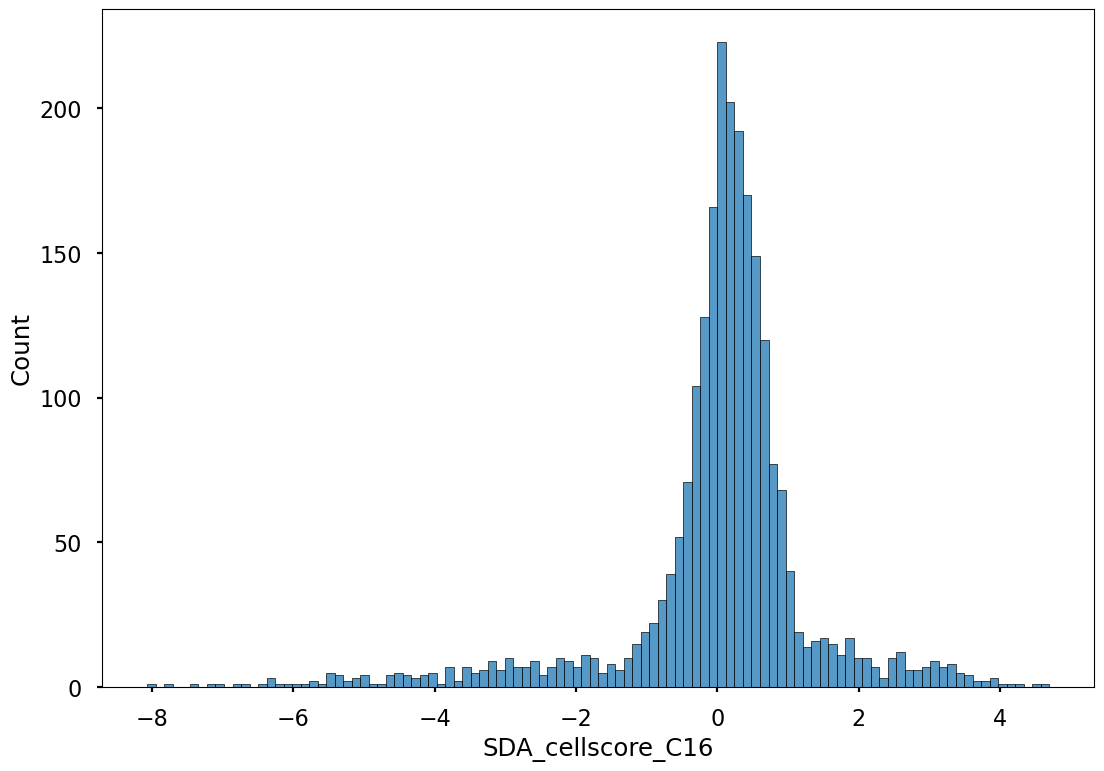

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C16: 543


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

MORN1
DDOST
CDC42
KDM1A
PITHD1
SRSF10
RSRP1
MACO1
PIGV
SNRNP40
HDAC1
SFPQ
PSMB2
CAP1
HSPB11
TMEM59
NFIA
TM2D1
DOCK7
EFCAB7
DEPDC1
PIGK
USP33
RPAP2
LOC100612616
DR1
DPYD
RNPC3
ATP5PB
RAP1A
HORMAD1
YY1AP1
SSR2
CCT3
NUF2
TMCO1
MAEL
CCDC181
SUCO
COP1
CEP350
SHCBP1L
TPR
UBE2T
ATP2B4
SLC30A1
NEK2
SRP9
LYST
RYR2
RGS7
DESI2
SH3YL1
PDIA6
DDX1
TTC32
ITSN2
NCOA1
ATRAID
SLC4A1AP
LTBP1
MORN2
LOC107973442
PPM1B
MCFD2
CFAP36
LOC100612368
RAB1A
C1D
LOC112208188
LOC107973594
SEPT10
UNC50
REV1
AFF3
PTPN4
UBXN4
GTDC1
MMADHC
PSMD14
B3GALT1
BBS5
PPIG
SCRN3
LNPK
MTX2
AGPS
GULP1
ORMDL1
HECW2
BOLL
C2BH2orf69
SGO2
UBE2F
CNTN4
RAD18
DAZL
UBE2E2
TOP2B
GOLGA4
NKTR
PRSS50
RBM5
TEX264
SELENOK
FAM208A
APPL1
PTPRG
C3H3orf14
THOC7
FOXP1
SHQ1
ROBO2
CRYBG3
TBC1D23
IFT57
SPICE1
ZBTB20
GOLGB1
IQCB1
UBA5
U2SURP
HLTF
SELENOT
TIPARP
MLF1
PPM1L
LRRC34
ECT2
NLGN1
MFN1
NDUFB5
SENP2
DNAJB11
RFC4
PPP1R2
TCTEX1D2
LRPAP1
LDB2
NCAPG
SLIT2
APBB2
HNRNPD
ART3
CDKL2
CHIC2
OCIAD1
NFXL1
PDHA2
MTTP
CENPE
PPA2
FAM241A
MAD2L1
INTU
HSPA4L
NAA

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C16: 603


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

MRPL20
SSU72
RPL22
ENO1
ACTL8
RPL11
NUDC
YTHDF2
CLSPN
MEAF6
MYCBP
PABPC4
CITED4
SCMH1
SVBP
RPS8
PRDX1
GPBP1L1
PIK3R3
AGBL4
ZFYVE9
SSBP3
JAK1
MSH4
SSX2IP
RPL5
ABCD3
LAMTOR5
CSDE1
S100A10
RPS27
TPM3
UBE2Q1
ASH1L
PFDN2
UAP1
CACYBP
ODR4
IPO9
PPP1R12B
SNRPE
NUCKS1
CENPF
PARP1
SIPA1L2
TARBP1
ACP1
ALKAL2
MYT1L
KLF11
ODC1
RAD51AP2
VSNL1
CEBPZ
SOCS5
MSH6
CCT4
ACTR2
GMCL1
EXOC6B
KCMF1
TGOLN2
UXS1
DDX18
EPB41L5
NIFK
TSN
PLEKHB2
MZT2B
CCNT2
ITGB6
SP3
CIR1
UBE2E3
SSFA2
ZNF804A
HSPD1
HSPE1
SUMO1
FAM117B
EEF1B2
KLF7
RPL37A
IGFBP2
TNP1
CAB39
NCL
PTMA
DGKD
LOC107973992
COPS9
TADA3
VGLL4
RAF1
RPL32
LSM3
SH3BP5
RPL15
RPSA
RPL14
KIF9
TMA7
RPL29
RPL24
STXBP5L
H1FX
CDV3
RYK
STAG1
ATP1B3
TBL1XR1
EIF4G1
RNF168
PAK2
NCBP2
LOC107970887
RGS12
RNF4
POLN
C4H4orf48
LOC107974525
ATP5ME
KIAA0232
TBC1D14
DCAF4L1
BEND4
LOC104006035
HNRNPDL
MRPL1
CNOT6L
CCNI
SDAD1
REST
USP46
HSD17B11
UBE2D3
RPL34
LOC107974385
MYOZ2
LOC104006217
SMARCA5
OTUD4
ARHGAP10
CDKN2AIP
FRG1
PLEKHG4B
MRPL36
NDUFS6
CCT5
LOC107974642
RPS23
JMY
AGGF1

#### Cells scores by cluster

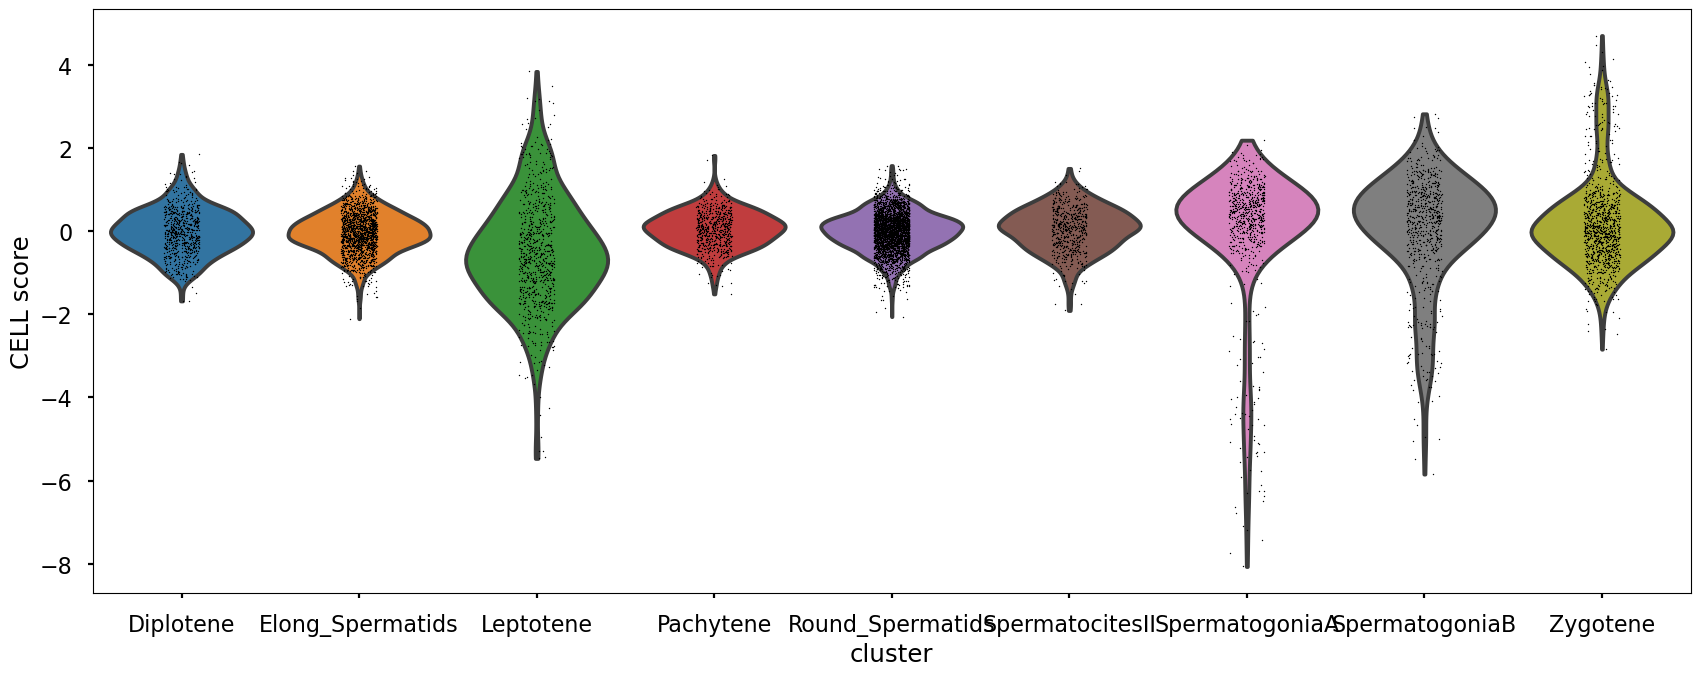

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

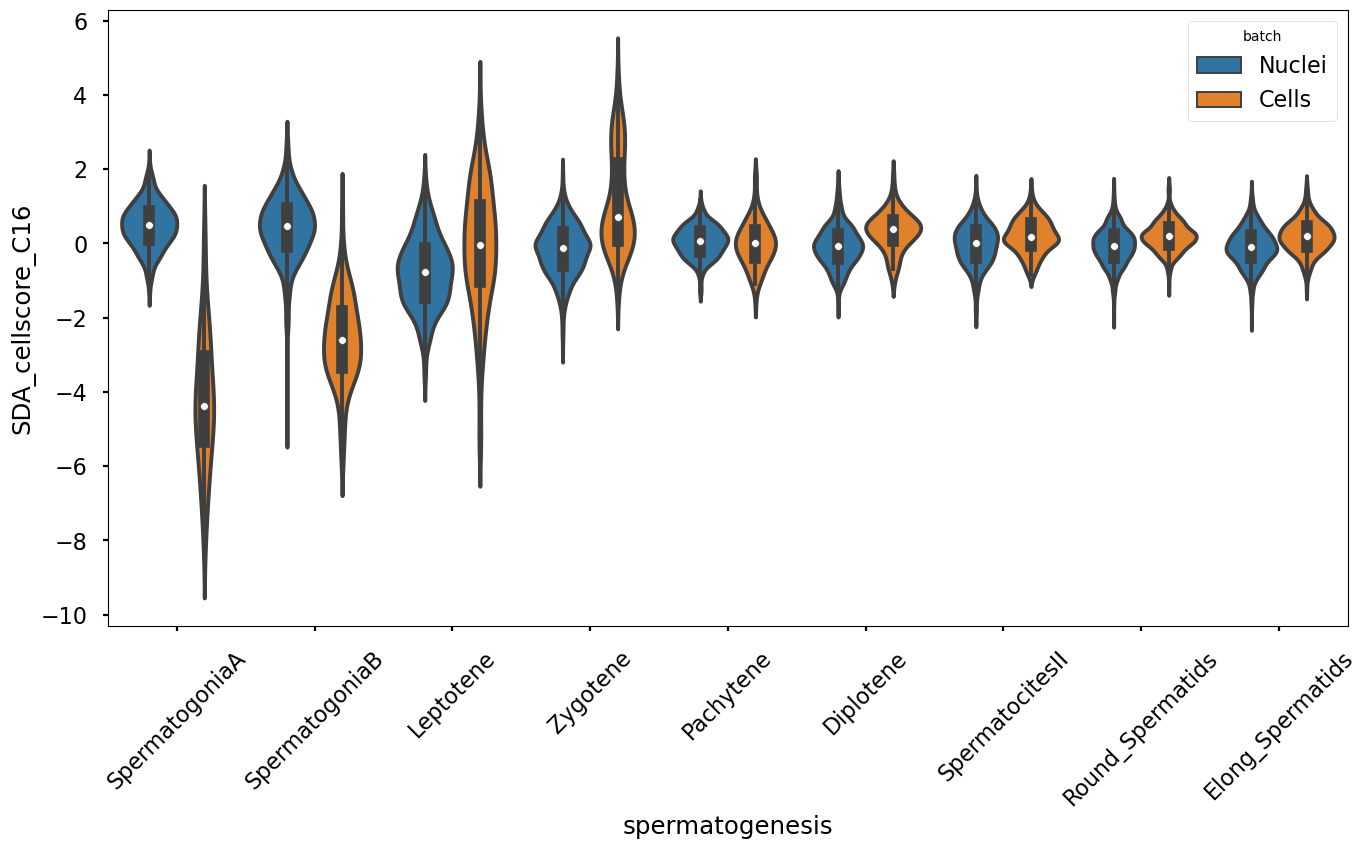

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C16')

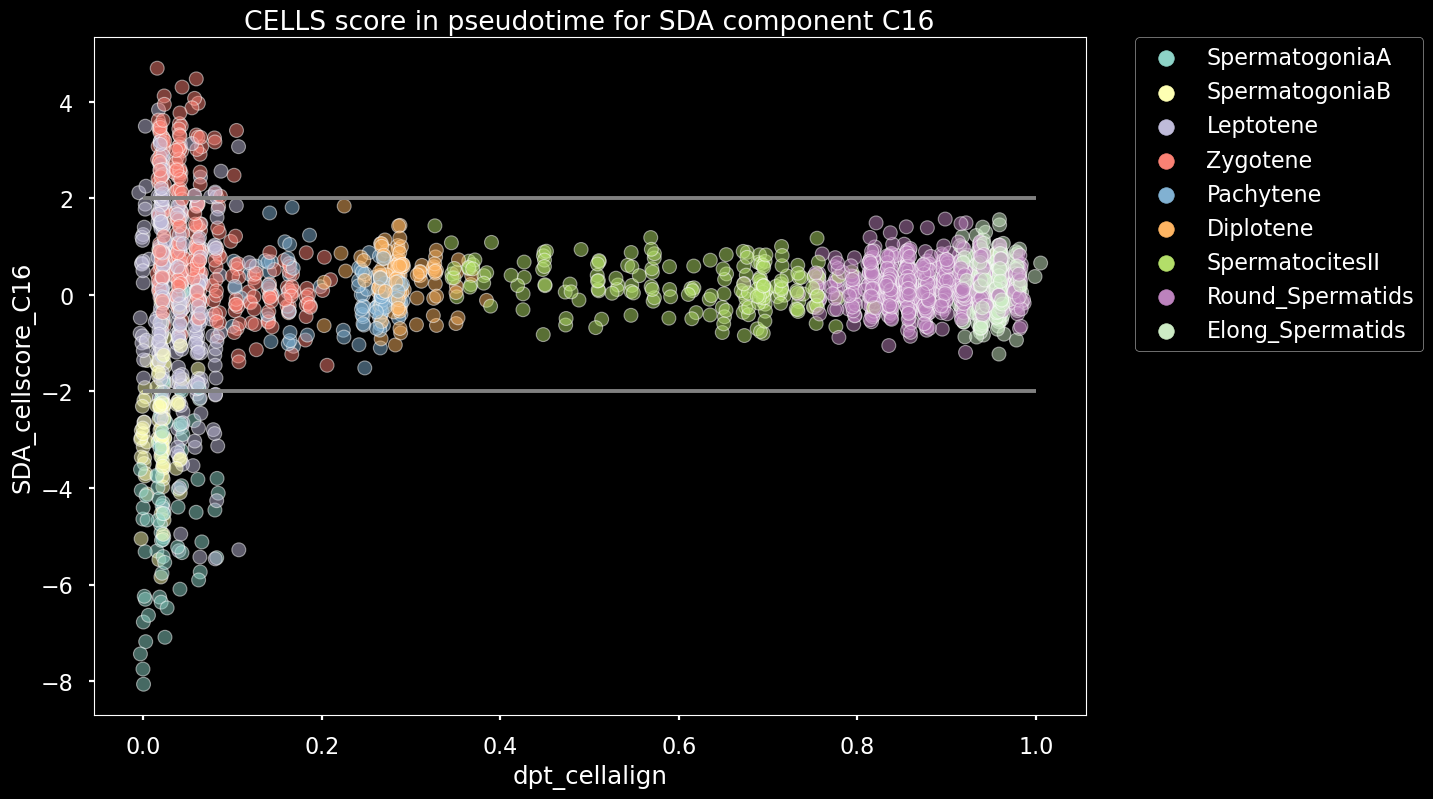

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C16')

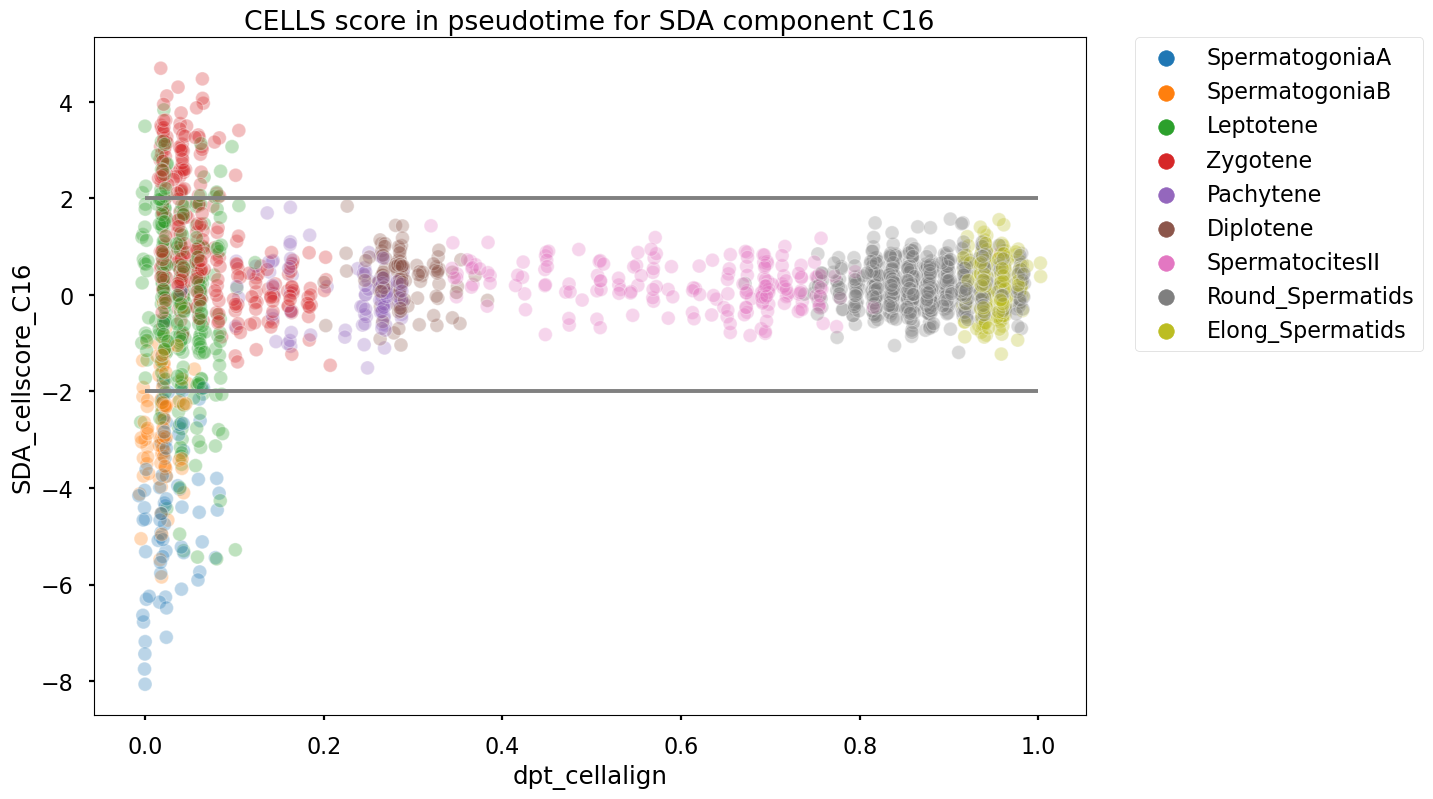

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C16')

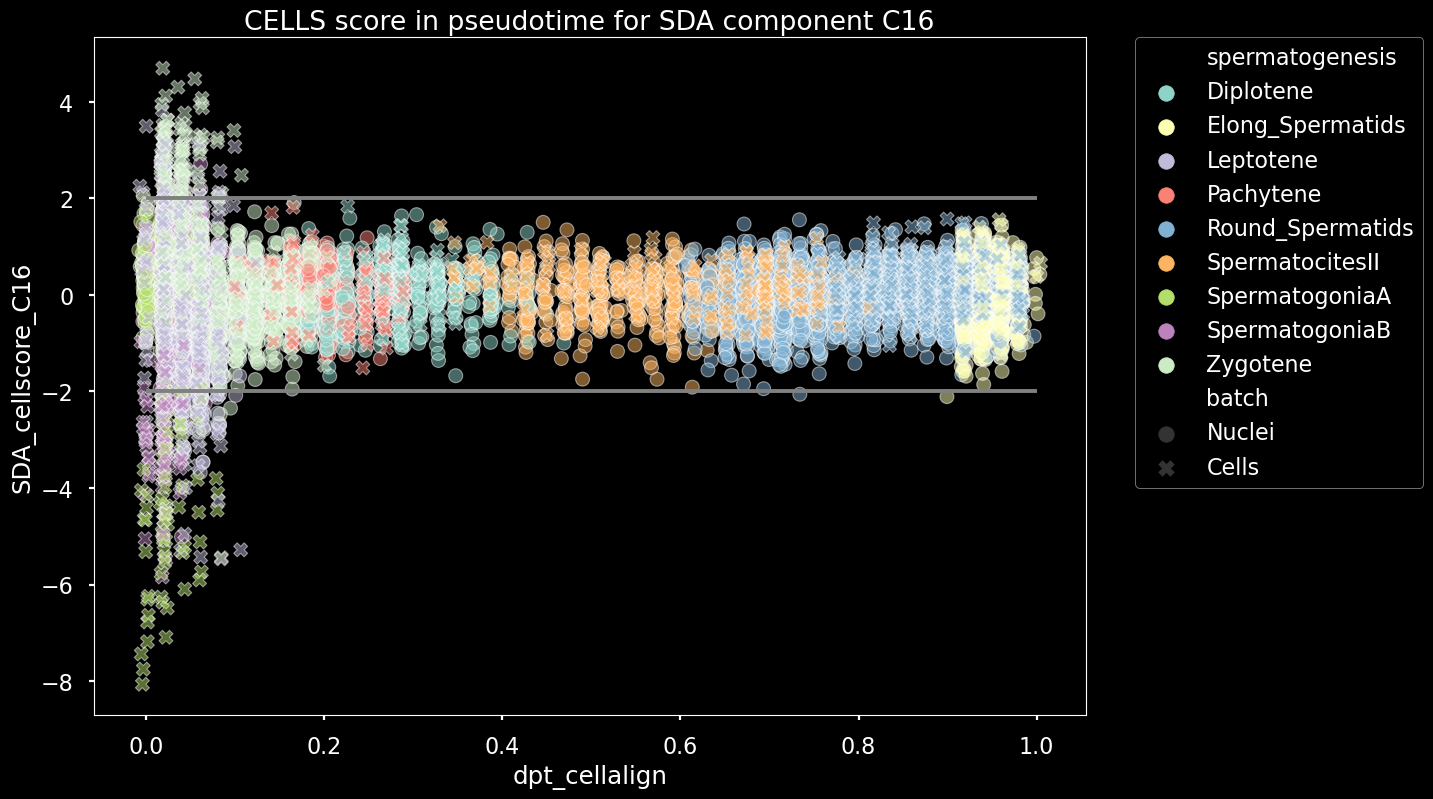

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C16')

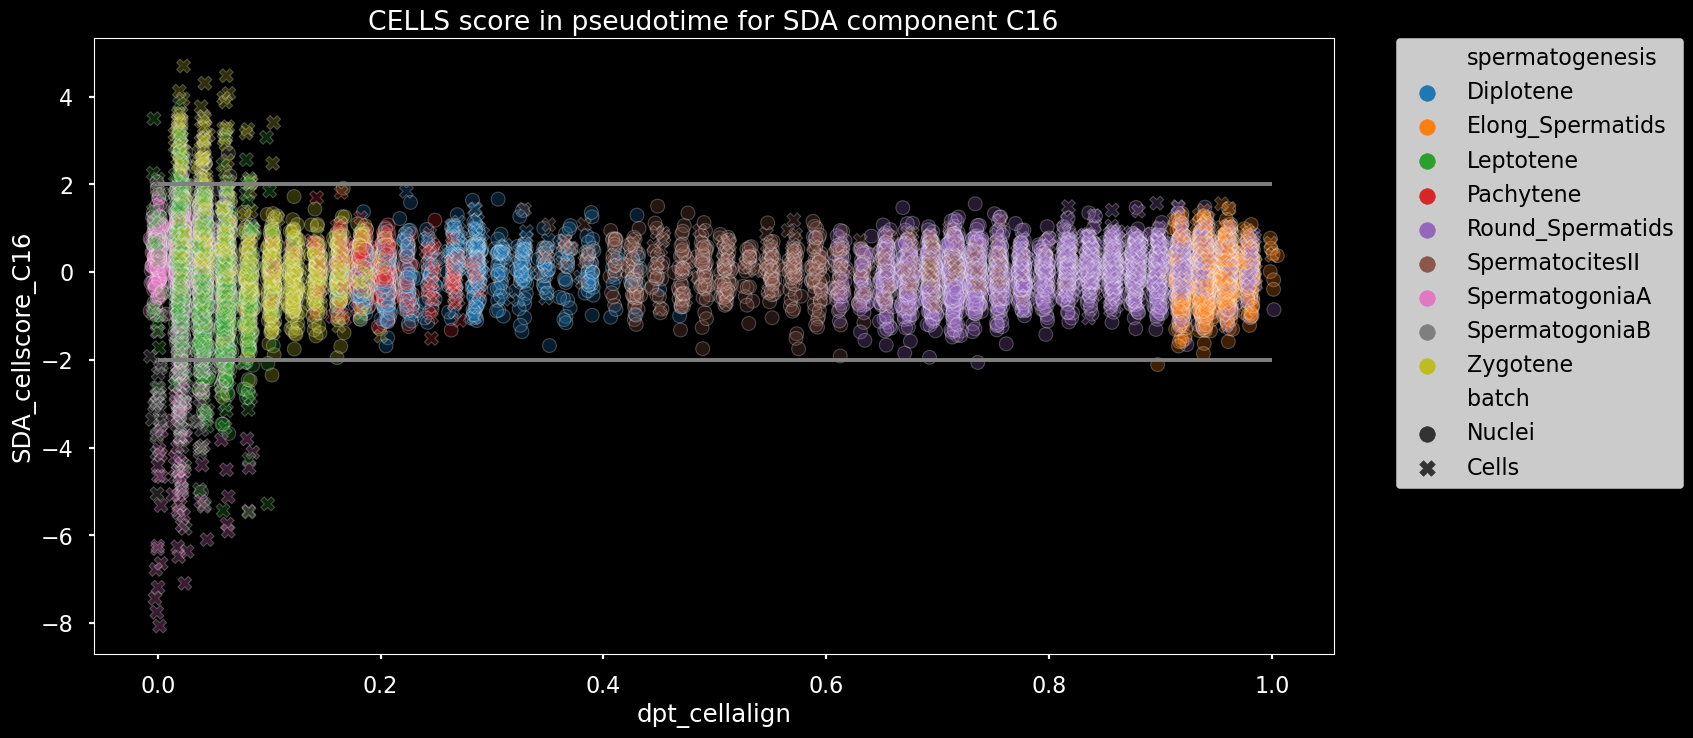

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,24/171,4.397656e-11,9.279055e-09,0,0,6.074476,144.860243,PDIA3;TRAM1;RPN2;HSPA5;SSR4;TUSC3;SAR1B;SSR2;H...
211,GO_Cellular_Component_2023,Endoplasmic Reticulum Membrane (GO:0005789),55/801,2.714004e-10,7.300670e-08,0,0,2.826839,62.267982,CALR3;RYR2;MCFD2;TRAM1;PIGN;TUSC3;GPAA1;PIGP;S...
212,GO_Cellular_Component_2023,Chromosome (GO:0005694),20/164,2.163736e-08,2.910224e-06,0,0,5.128798,90.517351,MDC1;CNTD1;UTP6;SPO11;RAD21L1;TEX12;NCAPG;SMC5...
213,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,190/5175,1.154239e-06,1.034968e-04,0,0,1.562580,21.363703,ITSN2;VPS29;MDC1;CHIC2;MTCH2;SLC4A1AP;KDM1A;TR...
214,GO_Cellular_Component_2023,Spindle (GO:0005819),19/210,4.924383e-06,3.311648e-04,0,0,3.657468,44.699052,IQCB1;DR1;BOD1;SHCBP1L;CBX1;SPICE1;CKAP2;BUB1B...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,24/171,9.279055e-09,6.074476,144.860243,PDIA3;TRAM1;RPN2;HSPA5;SSR4;TUSC3;SAR1B;SSR2;H...,16P,Yes,200
211,GO_Cellular_Component_2023,Endoplasmic Reticulum Membrane (GO:0005789),55/801,7.300670e-08,2.826839,62.267982,CALR3;RYR2;MCFD2;TRAM1;PIGN;TUSC3;GPAA1;PIGP;S...,16P,Yes,200
212,GO_Cellular_Component_2023,Chromosome (GO:0005694),20/164,2.910224e-06,5.128798,90.517351,MDC1;CNTD1;UTP6;SPO11;RAD21L1;TEX12;NCAPG;SMC5...,16P,Yes,200
213,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,190/5175,1.034968e-04,1.562580,21.363703,ITSN2;VPS29;MDC1;CHIC2;MTCH2;SLC4A1AP;KDM1A;TR...,16P,Yes,200
214,GO_Cellular_Component_2023,Spindle (GO:0005819),19/210,3.311648e-04,3.657468,44.699052,IQCB1;DR1;BOD1;SHCBP1L;CBX1;SPICE1;CKAP2;BUB1B...,16P,Yes,200


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,56/158,8.855465e-45,2.098745e-42,0,0,19.366240,1964.420266,RPL4;RPL5;RPL3;RPL32;RPL34;RPLP1;RPLP0;MRPL36;...
1,KEGG_2021_Human,Coronavirus disease,56/232,1.266704e-34,1.501045e-32,0,0,11.180572,872.660110,RPL4;RPL5;RPL3;RPL32;RPL34;RPLP1;RPLP0;RPL8;RP...
2,KEGG_2021_Human,Prion disease,26/273,2.541507e-07,2.007790e-05,0,0,3.493569,53.051032,NDUFB9;NDUFA13;NDUFB7;COX4I1;ATP5MC2;PIK3R3;IT...
3,KEGG_2021_Human,Huntington disease,26/306,2.234319e-06,1.323834e-04,0,0,3.076516,40.030323,NDUFB9;NDUFA13;HDAC2;NDUFB7;DNAH8;COX4I1;ATP5M...
4,KEGG_2021_Human,Diabetic cardiomyopathy,20/203,3.641426e-06,1.474580e-04,0,0,3.601871,45.106716,ATP5PF;NDUFB9;NDUFA13;NDUFA7;ATP5PD;NDUFB7;PAR...
5,KEGG_2021_Human,RNA transport,19/186,3.733115e-06,1.474580e-04,0,0,3.746309,46.822369,EIF4A1;UPF1;UBE2I;POP1;EIF1AX;NCBP2;PABPC4;CAS...
6,KEGG_2021_Human,Thermogenesis,21/232,7.954117e-06,2.510740e-04,0,0,3.280940,38.524211,ATP5PF;NDUFB9;NDUFA13;NDUFA7;ATP5PD;NDUFB7;COX...
7,KEGG_2021_Human,Adherens junction,11/71,8.475073e-06,2.510740e-04,0,0,5.988373,69.934500,PTPN1;CREBBP;CSNK2A2;MAPK1;WASL;RAC1;ACP1;SSX2...
8,KEGG_2021_Human,Oxidative phosphorylation,15/133,1.185516e-05,3.121860e-04,0,0,4.167892,47.275341,NDUFB9;ATP5PF;NDUFA13;NDUFA7;NDUFB7;ATP5PD;COX...
9,KEGG_2021_Human,Amyotrophic lateral sclerosis,27/364,1.764778e-05,4.046963e-04,0,0,2.651150,29.016571,NDUFB9;NDUFA13;NDUFB7;DNAH8;COX4I1;ATP5MC2;UQC...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,56/158,2.098745e-42,19.366240,1964.420266,RPL4;RPL5;RPL3;RPL32;RPL34;RPLP1;RPLP0;MRPL36;...,16N,Yes,346
1,KEGG_2021_Human,Coronavirus disease,56/232,1.501045e-32,11.180572,872.660110,RPL4;RPL5;RPL3;RPL32;RPL34;RPLP1;RPLP0;RPL8;RP...,16N,Yes,346
2,KEGG_2021_Human,Prion disease,26/273,2.007790e-05,3.493569,53.051032,NDUFB9;NDUFA13;NDUFB7;COX4I1;ATP5MC2;PIK3R3;IT...,16N,Yes,346
3,KEGG_2021_Human,Huntington disease,26/306,1.323834e-04,3.076516,40.030323,NDUFB9;NDUFA13;HDAC2;NDUFB7;DNAH8;COX4I1;ATP5M...,16N,Yes,346
4,KEGG_2021_Human,Diabetic cardiomyopathy,20/203,1.474580e-04,3.601871,45.106716,ATP5PF;NDUFB9;NDUFA13;NDUFA7;ATP5PD;NDUFB7;PAR...,16N,Yes,346
5,KEGG_2021_Human,RNA transport,19/186,1.474580e-04,3.746309,46.822369,EIF4A1;UPF1;UBE2I;POP1;EIF1AX;NCBP2;PABPC4;CAS...,16N,Yes,346
6,KEGG_2021_Human,Thermogenesis,21/232,2.510740e-04,3.280940,38.524211,ATP5PF;NDUFB9;NDUFA13;NDUFA7;ATP5PD;NDUFB7;COX...,16N,Yes,346
7,KEGG_2021_Human,Adherens junction,11/71,2.510740e-04,5.988373,69.934500,PTPN1;CREBBP;CSNK2A2;MAPK1;WASL;RAC1;ACP1;SSX2...,16N,Yes,346
8,KEGG_2021_Human,Oxidative phosphorylation,15/133,3.121860e-04,4.167892,47.275341,NDUFB9;ATP5PF;NDUFA13;NDUFA7;NDUFB7;ATP5PD;COX...,16N,Yes,346
9,KEGG_2021_Human,Amyotrophic lateral sclerosis,27/364,4.046963e-04,2.651150,29.016571,NDUFB9;NDUFA13;NDUFB7;DNAH8;COX4I1;ATP5MC2;UQC...,16N,Yes,346


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

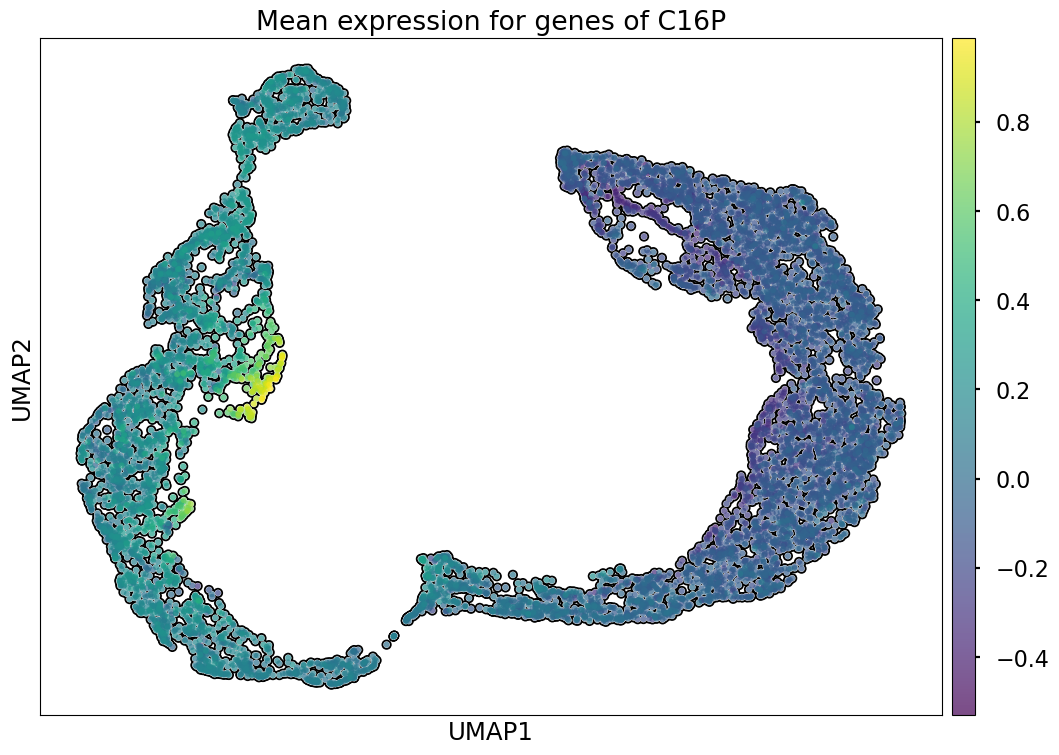

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

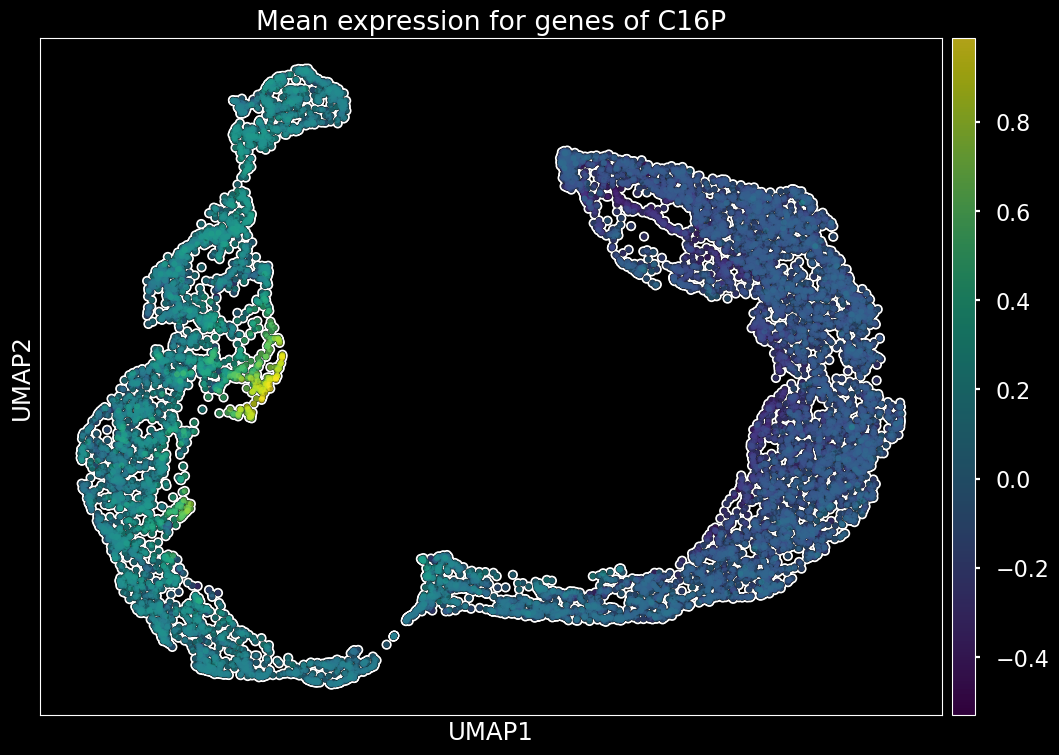

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

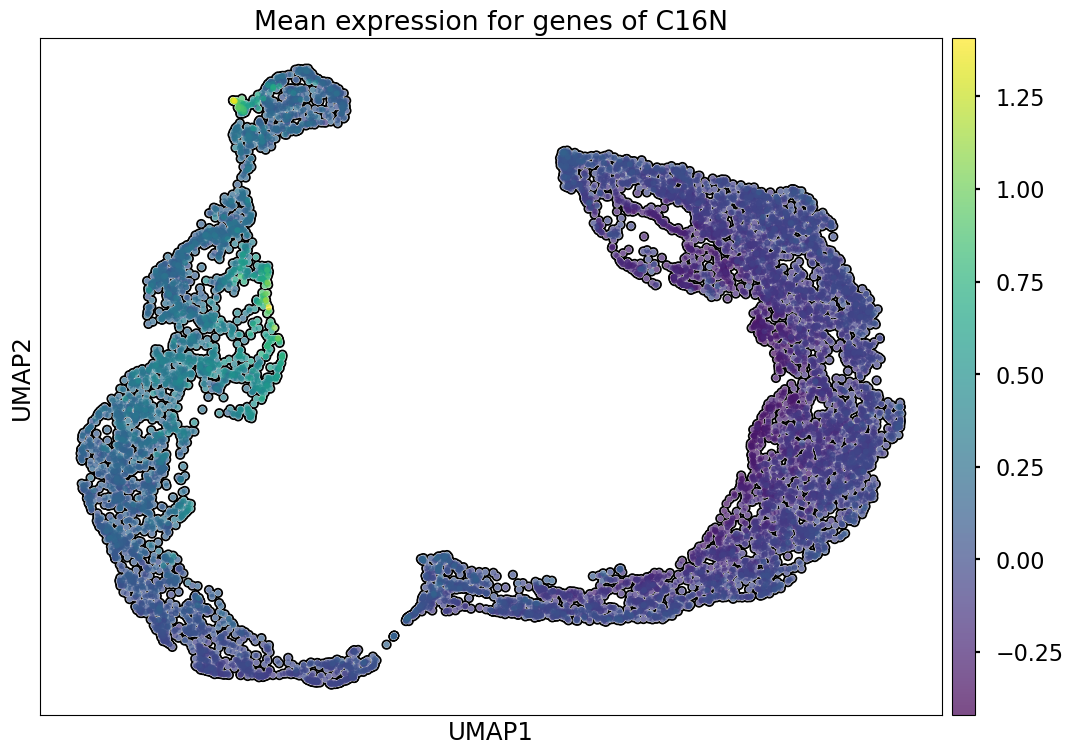

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

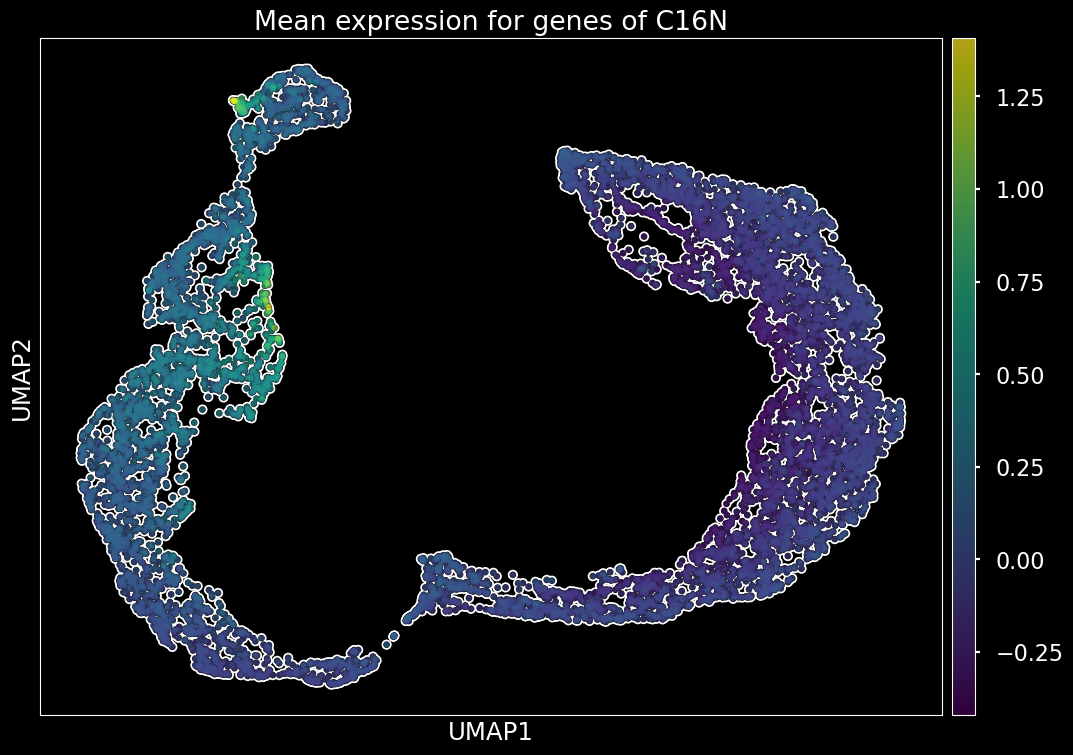

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)